# Build A Basic Chatbot

In [103]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [104]:
class State(TypedDict):
    # Messages have the type "list". The "add_messages" function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [105]:
graph_builder

In [106]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [107]:
from groq import Groq

client = Groq()

models = client.models.list()

for model in models.data:
    print(model.id)

canopylabs/orpheus-v1-english
openai/gpt-oss-20b
groq/compound
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.8-27b
whisper-large-v3
allam-2-7b
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m
whisper-large-v3-turbo
openai/gpt-oss-120b
groq/compound-mini
openai/gpt-oss-safeguard-20b
qwen/qwen3.6-27b


In [108]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [109]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000018AF2559810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018AF2A65A70>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [110]:
def chatbot(state):
    return {"messages": [llm.invoke(state["messages"])]}

In [111]:
graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot", chatbot)

# Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

#compile the graph
graph = graph_builder.compile()



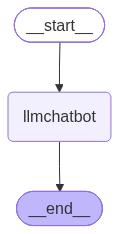

In [112]:
#visulize the graph
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [113]:
response=graph.invoke({"messages": ["Hello!"]})

In [114]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [115]:
for event in     graph.stream({"messages": ["Hello! how are you?"]}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great—thanks for asking. How can I help you today?


chatbot with tools


In [116]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=2)
tool.invoke("what is the capital of France?")

{'query': 'what is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://brainly.in/question/62118432',
   'title': 'What is the capital city of France and why is it famous?',
   'content': 'Answer:\n\nThe capital city of France is Paris.\n\nIt’s famous for several reasons:\n\nCultural heritage – Paris is home to iconic landmarks like the Eiffel Tower, Louvre Museum (housing the Mona Lisa), and Notre-Dame Cathedral.\n\nFashion capital – Known as the global hub for fashion and luxury brands, hosting events like Paris Fashion Week.\n\nHistory – The city has played a major role in European history, from the French Revolution to modern politics. [...] meham495   meham495\n\n Geography\n Secondary School\n\n# What is the capital city of France and why is it famous?\n\nkhanmoominah   khanmoominah\n\nAnswer:\n\nParis is the capital of France, famous for its history, culture, and beauty. Known as the “City of Light,” it has landmar

In [117]:
## custom function
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: the result of multiplying a and b.
    """
    return a * b

In [118]:
tools=[tool, multiply]

In [119]:
llm_with_tools=llm.bind_tools(tools)

In [120]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000018AF2559810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018AF2A65A70>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

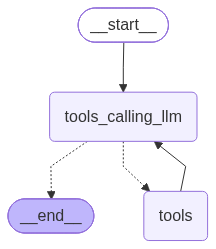

In [121]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


#graph definition
builder = StateGraph(State)
builder.add_node("tools_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

#edges
builder.add_edge(START, "tools_calling_llm")
builder.add_conditional_edges("tools_calling_llm",tools_condition)

builder.add_edge("tools", "tools_calling_llm")

#compile the graph
graph = builder.compile()

#visulize the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [122]:
response=graph.invoke({"messages": ["what is the recent ai news?"]})

In [123]:
response["messages"][-1].content

'**Recent AI News (September\u202f2026)**  \n\n| Date | Headline | Key Take‑aways | Source |\n|------|----------|----------------|--------|\n| **2\u202fSep\u202f2026** | *US pushes looser approach to AI regulation, while EU pushes new law* | • The U.S. hosted a G20 “innovation” ministerial meeting in Chapel\u202fHill, North\u202fCarolina, where officials urged the world to relax AI‑specific regulations, prioritising industry growth over regulatory constraints.  <br>• The EU, by contrast, is moving forward with its AI Act, tightening rules on high‑risk AI systems.  <br>• The divergent positions highlight a growing divide between the two blocs on how to govern AI. | Al\u202fJazeera/Reuters (link) |\n| **2\u202fSep\u202f2026** | *Top AI Healthcare Stocks for September\u202f2026* | • Companies such as **Tempus\u202fAI** and **Medtronic** are highlighted for their AI‑driven healthcare innovations. <br>• Tempus is expanding its genomic‑testing and cardiovascular AI tools, while Medtronic is 

In [124]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_146fb943-7e34-49fa-b5cd-ac2ef6e15a3b)
 Call ID: fc_146fb943-7e34-49fa-b5cd-ac2ef6e15a3b
  Args:
    query: recent AI news 2026 September
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://simplywall.st/stocks/us/pharmaceuticals-biotech/nyse-pfe/pfizer/news/top-ai-healthcare-stocks-for-september-2026", "title": "Top AI Healthcare Stocks For September 2026", "content": "Market Cap: US$11.4b\n\nTempus AI offers direct exposure to an AI in healthcare strategy, where each new genomic test, ECG analysis, and data licensing deal can

In [125]:
response=graph.invoke({"messages": [" give me the recent ai news then multiply 2 by 3?"]})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

 give me the recent ai news then multiply 2 by 3?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_532ef5d6-c547-4aed-82f9-081f1c6074b7)
 Call ID: fc_532ef5d6-c547-4aed-82f9-081f1c6074b7
  Args:
    query: recent AI news 2026
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.hpcwire.com/aiwire/2026/09/02/ddc-to-cool-duos-edge-ais-high-density-gpu-infrastructure-in-georgia", "title": "DDC to Cool Duos Edge AI’s High-Density GPU Infrastructure in Georgia", "content": "## Off the Wire\n\n##### AI Headlines\n\n### September 2, 2026\n\n   Wonderful Raises $550M Series C to Scale the AI Operating System for the Enterprise\n   EEAI 2

ADDING MEMEORY IN THE AGENTIC AI

In [126]:
response=graph.invoke({"messages": [" hello my name is naveen"]})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

 hello my name is naveen
================================== Ai Message ==================================

Hello Naveen! How can I help you today?


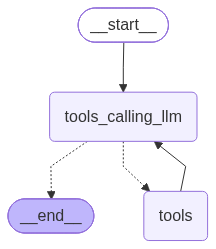

In [127]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
#node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


#graph definition
builder = StateGraph(State)
builder.add_node("tools_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

#edges
builder.add_edge(START, "tools_calling_llm")
builder.add_conditional_edges("tools_calling_llm",tools_condition)

builder.add_edge("tools", "tools_calling_llm")

#compile the graph
graph = builder.compile(checkpointer=memory)

#visulize the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [128]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"hi i am naveen how ru doing"},config=config)

In [129]:
response["messages"][-1].content

"Hi Naveen! I'm just a bundle of code, so I don't have feelings, but I'm ready to help you with whatever you need. How can I assist you today?"

In [130]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"what is my name"},config=config)
response["messages"][-1].content

'Your name is Naveen.'

streamming

In [132]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

In [136]:
def superbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

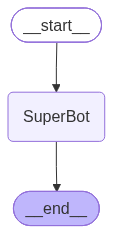

In [137]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [139]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke(
    {"messages": "Hi, My name is naveen and I like table tennis"},
    config
)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='eb67a713-62ee-4675-9c91-d71cf7e5b152'),
  AIMessage(content='Hey Krish! Great to meet you. Cricket’s a fantastic sport—so many exciting moments and legendary players. Do you have a favorite team or cricketer you follow? Or maybe there’s a particular match that still gets you excited? Let me know!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". The user hasn\'t asked a question or requested anything. We can respond with a friendly reply acknowledging name and interest in cricket, maybe ask about favorite cricket team or player. The user might want conversation. The conversation policy: we can talk about cricket. There\'s no policy violation. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 137, 'prompt_tokens': 82, 'total_tokens': 219, 'completion_time': 0.161053435, 'completion_tokens_d

In [144]:

config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is naveen and I like table tennis"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Naveen! 👋 It sounds like table tennis is a real passion of yours. Are you a casual player, or do you compete in local leagues? What’s your favorite part of the game—those quick back‑hand exchanges, the spin tricks, or the mental chess? Let me know how I can help—whether you’re looking for gear tips, training drills, or just want to chat about your latest matches!', additional_kwargs={'reasoning_content': "The user repeats the same greeting. We can respond politely and ask about their interests. It's repetitive. We can provide a friendly reply."}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 269, 'total_tokens': 392, 'completion_time': 0.155589018, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.023278491, 'prompt_tokens_details': None, 'queue_time': 0.305294157, 'total_time': 0.178867509}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': '

In [145]:
for chunk in graph_builder.stream({"messages":"i also like to play football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is naveen and I like table tennis', additional_kwargs={}, response_metadata={}, id='d5ef6c58-db39-441d-a7ea-c47f71bc9684'), AIMessage(content='Hello Naveen! 👋 It’s great to meet another table‑tennis enthusiast. What do you enjoy most about the sport—fast rallies, the spin, the strategy, or maybe the social side? Are you a casual player, or do you compete in leagues or tournaments? Let me know!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is naveen and I like table tennis". Probably a greeting. We should respond politely, maybe ask about table tennis, maybe ask what they like about it. No policy issues. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 83, 'total_tokens': 206, 'completion_time': 0.148005177, 'completion_tokens_details': {'reasoning_tokens': 53}, 'prompt_time': 0.017343105, 'prompt_tokens_details': None, 'queue_time': 0.314760043, 'tot

human in the loop

In [155]:
import os
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000018AF6C2C490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018AF6C2CD10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [156]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""

    human_response = interrupt({"query": query})

    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])

    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.

    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)



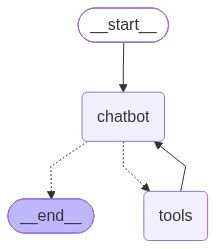

In [157]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [158]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_5256e7fc-5f14-4664-b6b5-f56b4da245fc)
 Call ID: fc_5256e7fc-5f14-4664-b6b5-f56b4da245fc
  Args:
    query: I need some expert guidance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_5256e7fc-5f14-4664-b6b5-f56b4da245fc)
 Call ID: fc_5256e7fc-5f14-4664-b6b5-f56b4da245fc
  Args:
    query: I need some expert guidance for building an AI agent.


In [159]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_5256e7fc-5f14-4664-b6b5-f56b4da245fc)
 Call ID: fc_5256e7fc-5f14-4664-b6b5-f56b4da245fc
  Args:
    query: I need some expert guidance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent.It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

I’ve just reached out to the experts on your behalf. They’ve suggested looking into **LangGraph**—it’s a robust framework for building AI agents, offering more reliability and extensibility than many simpler solutions. If you’d like more details on how to get started with LangGraph or have specific questions about your use case, just let me know!
